# 1. Conjunto de dados
Para esse exerício, baixe o conjunto de dados BBC News Classification diposnível em https://www.kaggle.com/competitions/learn-ai-bbc/data

1.1. Baixe o dataset, carregue as amostras de treino e teste em um dataframe.

### 1.1.1 Configurar o Token da API do Kaggle

Para interagir com a API do Kaggle e baixar datasets, você precisa configurar sua chave de API. Por segurança, é recomendado usar o gerenciador de segredos do Google Colab.

1.  Clique no ícone **🔑 Secrets** no painel esquerdo.
2.  Clique em **+ New secret**.
3.  No campo **Name**, digite `KAGGLE_API_TOKEN`.
4.  No campo **Value**, cole o valor do seu token da API do Kaggle (ex: `KGAT_ce5c3e3c2f9c7c91f7e88b5b555d4971`).
5.  Certifique-se de que a opção **Notebook access** esteja ativada.

In [ ]:
import os
from google.colab import userdata

# Recupera o token da API do Kaggle do gerenciador de segredos
KAGGLE_API_TOKEN = userdata.get('KAGGLE_API_TOKEN')

# Define o token como uma variável de ambiente para que kagglehub possa encontrá-lo
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_API_TOKEN

print("Kaggle API token configurado com sucesso!")


Kaggle API token configurado com sucesso!


In [ ]:
import kagglehub

# Download latest version
# If you encounter a 401 Unauthorized error, please ensure you have accepted the competition rules on the Kaggle website:
# https://www.kaggle.com/competitions/learn-ai-bbc/rules
path = kagglehub.competition_download('learn-ai-bbc')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/learn-ai-bbc


In [ ]:
import os
import pandas as pd

# List the contents of the downloaded directory
print(f"Contents of {path}: {os.listdir(path)}")

try:
    # Load both training and testing datasets
    train_df = pd.read_csv(os.path.join(path, 'BBC News Train.csv'))

    print("Train data loaded successfully:")
    print(train_df.head())

except FileNotFoundError:
    print(f"Error: Data files not found in {path}. Please check the filenames.")
    print("Expected files like 'BBC News Train.csv' and 'BBC News Test.csv'")

Contents of /root/.cache/kagglehub/competitions/learn-ai-bbc: ['BBC News Test.csv', 'BBC News Train.csv', 'BBC News Sample Solution.csv']
Train data loaded successfully:
   ArticleId                                               Text  Category
0       1833  worldcom ex-boss launches defence lawyers defe...  business
1        154  german business confidence slides german busin...  business
2       1101  bbc poll indicates economic gloom citizens in ...  business
3       1976  lifestyle  governs mobile choice  faster  bett...      tech
4        917  enron bosses in $168m payout eighteen former e...  business


### 1.2. Extrair Textos e Categorias do conjunto de dados da BBC News

In [ ]:
import numpy as np

# Extract texts and labels from train_df
bbc_train_texts = train_df['Text'].tolist()
bbc_train_labels_str = train_df['Category'].tolist()


print(f"Primeiros 5 textos de treino da BBC: {bbc_train_texts[:1]}")
print(f"Primeiras 5 labels de treino da BBC: {bbc_train_labels_str[:5]}")


Primeiros 5 textos de treino da BBC: ['worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and conspiracy.  prosecution lawyers have argued that mr ebbers orchestrated a series of accounting tricks at worldcom  ordering employees to hide expenses and inflate revenues to meet wall street earnings estimates. but ms cooper  who now runs her own consulting business  told a jury in new york on wednesday that external auditors arthur andersen had approved worldcom s accounting in early 2001 and 2002. she said andersen had given a  green light  to the procedures 

###Q1) Explore os dados.
* a. Quantos textos existem no dataset?
* b. Desenhe um diagrama de barras com a quantidade de textos em cada classe. Responda.
* c. As classes possuem quantidades semelhantes de exemplos?
* d. Qual categoria possui mais registros?
* e. Qual categoria possui menos registros?
* f. Existe desbalanceamento entre classes?
* g. Exiba em um gráfico de caixa (boxplot) a distribuição do tamanho dos textos em cada classe. Responda:  Qual o tamanho médio dos textos?



In [ ]:
import matplotlib.pyplot as plt


Quantidade de textos no dataset: 1490


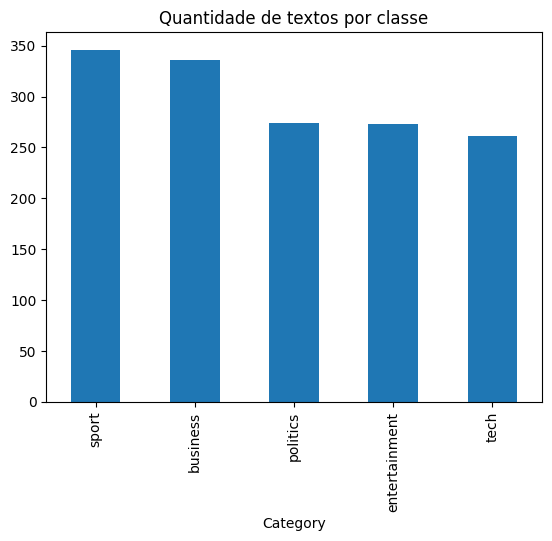

Classes com quantidades semelhantes de exemplos:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64
Categoria com mais registros:
sport
Categoria com menos registros:
tech
Existe desbalanceamento entre classes:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64
Distribuição do tamanho dos textos em cada classe:
Tamanho médio dos textos:
2233.461744966443


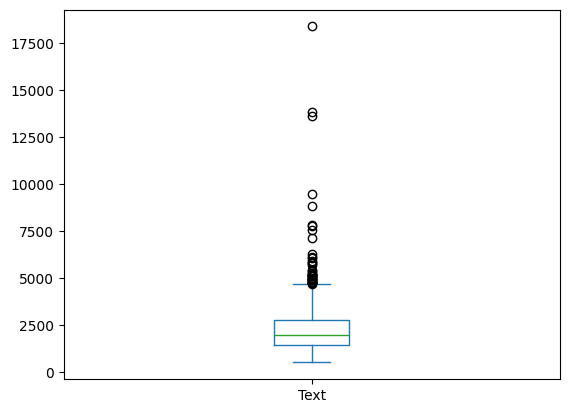

In [ ]:
train_df.columns

qntd_tex = len(train_df)
print(f"Quantidade de textos no dataset: {qntd_tex}")

train_df['Category'].value_counts().plot(kind='bar')
plt.title("Quantidade de textos por classe")
plt.show()

print("Classes com quantidades semelhantes de exemplos:")
print (train_df['Category'].value_counts())

print("Categoria com mais registros:")
print(train_df['Category'].value_counts().idxmax())

print("Categoria com menos registros:")
print(train_df['Category'].value_counts().idxmin())

print("Existe desbalanceamento entre classes:")
print(train_df['Category'].value_counts())

print("Distribuição do tamanho dos textos em cada classe:")
train_df.groupby('Category')['Text'].apply(lambda x: x.str.len()).plot(kind='box')

print("Tamanho médio dos textos:")
print(train_df.groupby('Category')['Text'].apply(lambda x: x.str.len()).mean())



### Separe 90% dos dados para treino e 10% para teste. Armazene o texto em bbc_train_texts e bbc_test_texts e as labels em y_bbc_train e y_bbc_test

In [ ]:
from sklearn.model_selection import train_test_split

bbc_train_texts, bbc_test_texts, y_bbc_train, y_bbc_test = train_test_split(train_df['Text'], train_df['Category'],  test_size=0.1, random_state=42)

print("Treino:", len(bbc_train_texts))
print("Teste:", len(bbc_test_texts))

Treino: 1341
Teste: 149


### Convertendo labels categóricas em numéricas

Vamos mapear as categorias para inteiros para que possam ser usadas no treinamento do modelo.

In [ ]:
import numpy as np
import pandas as pd

# Identificar categorias únicas do conjunto de dados completo para criar um mapeamento robusto
all_categories = sorted(list(train_df['Category'].unique()))
category_to_int = {category: i for i, category in enumerate(all_categories)}

# Converter labels de treino (do split) para números
# Verifica se y_bbc_train já é numérico. Se sim, usa diretamente. Caso contrário, converte de strings.
if isinstance(y_bbc_train, (np.ndarray, pd.Series)) and pd.api.types.is_integer_dtype(y_bbc_train):
    bbc_train_labels = np.array(y_bbc_train)
else:
    bbc_train_labels = np.array([category_to_int[cat] for cat in y_bbc_train])

# Converter labels de teste (do split) para números
# Verifica se y_bbc_test já é numérico. Se sim, usa diretamente. Caso contrário, converte de strings.
if isinstance(y_bbc_test, (np.ndarray, pd.Series)) and pd.api.types.is_integer_dtype(y_bbc_test):
    bbc_test_labels = np.array(y_bbc_test)
else:
    bbc_test_labels = np.array([category_to_int[cat] for cat in y_bbc_test])

print(f"Mapeamento de categorias: {category_to_int}")
print(f"Primeiras 5 labels numéricas de treino da BBC: {bbc_train_labels[:5]}")
print(f"Primeiras 5 labels numéricas de teste da BBC: {bbc_test_labels[:5]}")

Mapeamento de categorias: {'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}
Primeiras 5 labels numéricas de treino da BBC: [2 3 0 4 3]
Primeiras 5 labels numéricas de teste da BBC: [1 2 2 4 4]


### Camada de vetorização para os dados da BBC News

Observe o código abaixo e responda às perguntas.

* Q2) Como vocabulário pequeno demais pode prejudicar resultados?
* Q3) Como sequências muito curtas podem afetar classificação?
* Q4) Sequências muito longas trazem quais custos?
* Q5) Altere o código abaixo da camada de vetorização para considerar um  tamanho de vocabulário, bem como tamanho de textos mais adequados ao conjunto de dados em questão.


In [ ]:
from tensorflow.keras.layers import TextVectorization

# Camada de vetorização específica para o conjunto de dados da BBC News.
bbc_vectorize_layer = TextVectorization(
    max_tokens=100,
    output_mode='int',
    output_sequence_length=64,
    standardize='lower_and_strip_punctuation',
    split='whitespace'
)

# Adaptar a camada de vetorização aos textos de treino da BBC News
bbc_vectorize_layer.adapt(np.array(bbc_train_texts))

# Transformar os textos de treino da BBC News em sequências de inteiros preenchidas
X_bbc_train = bbc_vectorize_layer(np.array(bbc_train_texts)).numpy()

# Atribuir as labels extraídas da BBC News para y_bbc_train
y_bbc_train = bbc_train_labels

print(f"Shape de X_bbc_train (textos processados da BBC News): {X_bbc_train.shape}")
print(f"Shape de y_bbc_train (labels da BBC News): {y_bbc_train.shape}")

# Also print info for labels after conversion
print(f"Mapeamento de categorias: {category_to_int}")
print(f"Primeiras 5 labels numéricas de treino da BBC: {bbc_train_labels[:5]}")

Shape de X_bbc_train (textos processados da BBC News): (1341, 64)
Shape de y_bbc_train (labels da BBC News): (1341,)
Mapeamento de categorias: {'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}
Primeiras 5 labels numéricas de treino da BBC: [2 3 0 4 3]


### Processar os dados de teste da BBC News

* Q6) Aplicar a mesma camada de vetorização aos textos de teste da BBC News.

In [ ]:
X_bbc_test = bbc_vectorize_layer(np.array(bbc_test_texts)).numpy()

y_bbc_test = bbc_test_labels

print(f"Shape de X_bbc_test (textos processados da BBC News): {X_bbc_test.shape}")
print(f"Shape de y_bbc_test (labels da BBC News): {y_bbc_test.shape}")

Shape de X_bbc_test (textos processados da BBC News): (149, 64)
Shape de y_bbc_test (labels da BBC News): (149,)


## Definindo a rede neural
A rede neural pode ser vista como uma sequencia de camadas de transformação, a saída de uma camada é dada como entrada para a próxima camada.

* Q7) Qual modificação foi necessária para adaptar a rede à classificação com muitas classes? Compare com o exemplo dado na aula anterior.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

# Get the number of unique categories from the category_to_int mapping
num_classes = len(category_to_int)

model = Sequential([
    Embedding(input_dim=10000, output_dim=16, input_length=256),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


* Q8) Modifique a arquitetura da rede incluindo outra camada densa intermediária e compile o modelo. Quantos parâmetros treináveis tem seu modelo?

* Q9) Observe a alteração feita na entrada do método compile em relação ao exemplo da aula. Qual alteração foi feita e por quê?

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Embedding, Flatten, Dense, Input

model = Sequential([
    Input(shape=(200,)),
    Embedding(input_dim=10000, output_dim=16, input_length=256),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │       102,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,045 (1.00 MB)

 Trainable params: 263,045 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Treinamento do modelo


* Q10) No método para o treinamento, altere o número de épocas para obter um melhor valor de loss.

In [ ]:
# Converte X e y para tensores no TensorFlow
X_tensor = tf.constant(X_bbc_train, dtype=tf.int32)
y_tensor = tf.constant(y_bbc_train, dtype=tf.int32) # Labels should be int for sparse_categorical_crossentropy

model.fit(X_tensor, y_tensor, epochs=10, verbose=1)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 7.2717e-05
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 7.0561e-05
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 6.8594e-05
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 6.6755e-05
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 1.0000 - loss: 6.4694e-05
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 6.3010e-05
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 6.1216e-05
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 5.9527e-05
Epoch 9/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 5.7842e-05
Epoch 10/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 5.6171e-05


In [ ]:

# Converte X e y para tensores no TensorFlow
X_tensor = tf.constant(X_bbc_train, dtype=tf.int32)
y_tensor = tf.constant(y_bbc_train, dtype=tf.int32) # Labels should be int for sparse_categorical_crossentropy

model.fit(X_tensor, y_tensor, epochs=15, verbose=1)

Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 5.4556e-05
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 5.3065e-05
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 5.1621e-05
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 5.0326e-05
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 4.8849e-05
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 4.7702e-05
Epoch 7/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 4.6210e-05
Epoch 8/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 4.4940e-05
Epoch 9/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 4.3767e-05
Epoch 10/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 4.2630e-05
Epoch 11/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 4.1361e-05
Epoch 12/15
42/42 ━━━━━━━━━━━━

* Q11) Avalie o modelo usando a porção de dados de teste. Qual o resultado?



In [ ]:
X_test_tensor = tf.constant(X_bbc_test, dtype=tf.int32)
y_test_tensor = tf.constant(y_bbc_test, dtype=tf.int32)

loss, accuracy = model.evaluate(X_test_tensor, y_test_tensor)
print(f"Loss: {loss}, Accuracy: {accuracy}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5369 - loss: 3.4752  
Loss: 3.4751739501953125, Accuracy: 0.536912739276886


* Q12) Mostre como predizer a classe de um texto específico.

In [ ]:
train_df.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [ ]:
novo_text = ["german business confidence slides german business confidence fell in february knocking hopes of a speedy recovery in europe s largest economy. munich-based research institute ifo said that its confidence index fell to 95.5 in february from 97.5 in january its first decline in three months. the study found that the outlook in both the manufacturing and retail sectors had worsened. observers had been hoping that a more confident business sector would signal that economic activity was picking up. we re surprised that the ifo index has taken such a knock said dz bank economist bernd weidensteiner. the main reason is probably that the domestic economy is still weak particularly in the retail trade. economy and labour minister wolfgang clement called the dip in february s ifo confidence figure a very mild decline . he said that despite the retreat the index remained at a relatively high level and that he expected a modest economic upswing to continue. germany s economy grew 1.6% last year after shrinking in 2003. however the economy contracted by 0.2% during the last three months of 2004 mainly due to the reluctance of consumers to spend. latest indications are that growth is still proving elusive and ifo president hans-werner sinn said any improvement in german domestic demand was sluggish. exports had kept things going during the first half of 2004 but demand for exports was then hit as the value of the euro hit record levels making german products less competitive overseas. on top of that the unemployment rate has been stuck at close to 10% and manufacturing firms including daimlerchrysler siemens and volkswagen have been negotiating with unions over cost cutting measures. analysts said that the ifo figures and germany s continuing problems may delay an interest rate rise by the european central bank. eurozone interest rates are at 2% but comments from senior officials have recently focused on the threat of inflation prompting fears that interest rates may rise."]

novo_text_vetorizado = bbc_vectorize_layer(np.array(novo_text)).numpy()

novo_texto_tensor = tf.constant(novo_text_vetorizado, dtype=tf.int32)

predicao = model.predict(novo_texto_tensor)

classe_predicao = np.argmax(predicao)

print(f"Predição: {classe_predicao}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predição: 0


In [ ]:
int_to_category = {v: k for k, v in category_to_int.items()}

print("Classe prevista:", int_to_category[1])

Classe prevista: entertainment
